#  Heart Disease Prediction - Model Inference

**Author:** Pronab Sardar  

## Purpose
Demonstrate loading the trained model and making predictions on new patient data:
1. Load the trained pickle model
2. Load model from MLflow registry
3. Make single & batch predictions
4. Call the deployed FastAPI endpoint

## 1. Import Libraries

In [1]:
import os
import sys
import joblib
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn

sys.path.insert(0, os.path.abspath('..'))
print('Libraries loaded!')

Libraries loaded!


## 2. Load Model from Pickle

In [2]:
MODEL_PATH = '../models/best_model.pkl'
model = joblib.load(MODEL_PATH)
print(f'Model loaded from: {MODEL_PATH}')
print(f'Model type: {type(model).__name__}')
print(f'Pipeline steps: {list(model.named_steps.keys())}')

Model loaded from: ../models/best_model.pkl
Model type: Pipeline
Pipeline steps: ['preprocessor', 'classifier']


## 3. Single Patient Prediction

In [3]:
# Sample patient (high-risk profile)
patient_1 = pd.DataFrame([{
    'age': 63, 'sex': 1, 'cp': 3, 'trestbps': 145, 'chol': 233,
    'fbs': 1, 'restecg': 0, 'thalach': 150, 'exang': 0,
    'oldpeak': 2.3, 'slope': 0, 'ca': 0, 'thal': 1
}])

pred = model.predict(patient_1)[0]
proba = model.predict_proba(patient_1)[0]

print(f'Patient Profile:')
print(patient_1.iloc[0])
print(f'\nPrediction: {"HIGH RISK (Disease)" if pred == 1 else "LOW RISK (No Disease)"}')
print(f'Confidence: {proba.max():.2%}')
print(f'Probability breakdown:')
print(f'  No Disease: {proba[0]:.2%}')
print(f'  Disease:    {proba[1]:.2%}')

Patient Profile:
age          63.0
sex           1.0
cp            3.0
trestbps    145.0
chol        233.0
fbs           1.0
restecg       0.0
thalach     150.0
exang         0.0
oldpeak       2.3
slope         0.0
ca            0.0
thal          1.0
Name: 0, dtype: float64

Prediction: LOW RISK (No Disease)
Confidence: 63.71%
Probability breakdown:
  No Disease: 63.71%
  Disease:    36.29%


## 4. Batch Prediction

In [4]:
# Load test dataset for batch inference
df = pd.read_csv('../data/raw/heart_disease.csv')
sample_batch = df.drop('target', axis=1).sample(n=10, random_state=42)

# Predict on batch
predictions = model.predict(sample_batch)
probabilities = model.predict_proba(sample_batch)

# Prepare results
results = sample_batch.copy()
results['prediction'] = predictions
results['confidence'] = probabilities.max(axis=1)
results['risk_label'] = results['prediction'].map({0: 'Low Risk', 1: 'High Risk'})

print('Batch Prediction Results:')
results[['age', 'sex', 'chol', 'thalach', 'prediction', 'risk_label', 'confidence']]

Batch Prediction Results:


,age,sex,chol,thalach,prediction,risk_label,confidence
179,53.0,1.0,246.0,173.0,0,Low Risk,0.780811
228,54.0,1.0,206.0,108.0,1,High Risk,0.780103
111,56.0,1.0,249.0,144.0,1,High Risk,0.848344
246,58.0,1.0,234.0,156.0,1,High Risk,0.667198
60,51.0,0.0,305.0,142.0,1,High Risk,0.623634
9,53.0,1.0,203.0,155.0,1,High Risk,0.769090
119,65.0,1.0,254.0,127.0,1,High Risk,0.948287
223,53.0,1.0,282.0,95.0,1,High Risk,0.952730
268,40.0,1.0,223.0,181.0,0,Low Risk,0.609323
33,59.0,1.0,234.0,161.0,1,High Risk,0.613442


## 5. Load Model from MLflow Registry

In [8]:
# Load from MLflow Model Registry (Production stage)
try:
    mlflow.set_tracking_uri('file:../mlruns')
    model_uri = 'models:/HeartDiseasePredictor_Pronab_LogisticRegression/Production'
    mlflow_model = mlflow.sklearn.load_model(model_uri)
    print(f'Model loaded from MLflow Registry: {model_uri}')
    
    # Test prediction
    pred = mlflow_model.predict(patient_1)
    print(f'Prediction from registry model: {pred[0]}')
except Exception as e:
    print(f'Registry load failed (expected if not yet promoted): {e}')

Model loaded from MLflow Registry: models:/HeartDiseasePredictor_Pronab_LogisticRegression/Production
Prediction from registry model: 0


## 6. Call Deployed FastAPI Endpoint

In [9]:
# Make sure the API is running: uvicorn src.api:app --reload
API_URL = 'http://localhost:8000/predict'

payload = {
    'age': 55, 'sex': 1, 'cp': 3, 'trestbps': 140, 'chol': 250,
    'fbs': 0, 'restecg': 1, 'thalach': 150, 'exang': 0,
    'oldpeak': 1.5, 'slope': 2, 'ca': 0, 'thal': 2
}

try:
    response = requests.post(API_URL, json=payload, timeout=5)
    if response.status_code == 200:
        print(f'API Response:')
        print(response.json())
    else:
        print(f'API Error: {response.status_code}')
except requests.exceptions.ConnectionError:
    print('API not reachable. Start with: uvicorn src.api:app --reload')

API Response:
{'prediction': 0, 'confidence': 0.6307817676510805, 'risk_label': 'Low Risk'}


## 7. Visualize Prediction Distribution

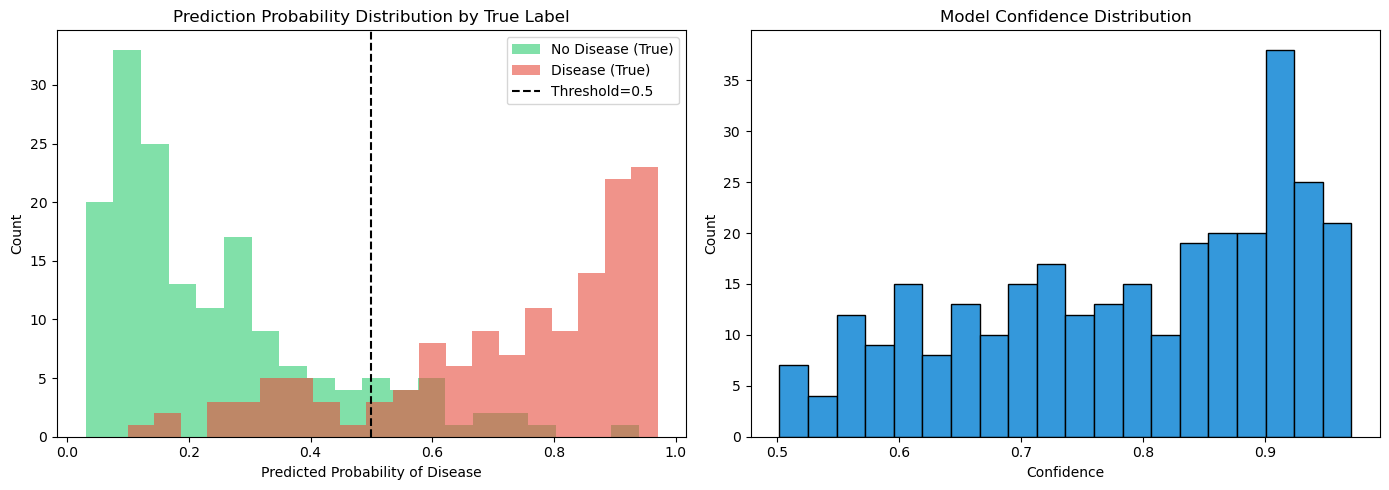

In [10]:
# Predict on entire dataset for visualization
X_all = df.drop('target', axis=1)
y_all = df['target']
all_preds = model.predict(X_all)
all_probas = model.predict_proba(X_all)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of probabilities by true label
axes[0].hist(all_probas[y_all == 0], bins=20, alpha=0.6, label='No Disease (True)', color='#2ecc71')
axes[0].hist(all_probas[y_all == 1], bins=20, alpha=0.6, label='Disease (True)', color='#e74c3c')
axes[0].axvline(0.5, color='black', linestyle='--', label='Threshold=0.5')
axes[0].set_title('Prediction Probability Distribution by True Label')
axes[0].set_xlabel('Predicted Probability of Disease')
axes[0].set_ylabel('Count')
axes[0].legend()

# Confidence distribution
confidences = np.maximum(all_probas, 1 - all_probas)
axes[1].hist(confidences, bins=20, color='#3498db', edgecolor='black')
axes[1].set_title('Model Confidence Distribution')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../screenshots/mlflow/inference_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## Summary

This notebook demonstrated:
1.  Loading model from pickle file
2.  Single patient prediction with confidence
3.  Batch prediction on multiple patients
4.  Loading model from MLflow Registry (Production stage)
5.  Calling the deployed FastAPI endpoint
6.  Visualizing prediction distributions

The model is **ready for production inference**! 

---
**Author:** Pronab Sardar 